In [3]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import hanoi


Read data

In [2]:
d = pd.read_csv("data/L1_n1/L1_n1_step.txt", delimiter=" ")

In [3]:
d.head()

,m0,m1,v0,v1,n_gen,allele_fixed
0,0.0,0.0,0.01,0.01,1,NaN
1,0.0,0.0,0.01,0.01,1,NaN
2,0.0,0.0,0.01,0.01,1,NaN
3,0.0,0.0,0.01,0.01,1,NaN
4,0.0,0.0,0.01,0.01,1,NaN


In [4]:
d_gb = d.groupby(["m0", "m1", "v0", "v1"])

Extinction prob.

In [5]:
d_gb.agg(p_ext = ("allele_fixed", lambda x: x.isna().sum()/x.size),
         p_fix_1 = ("allele_fixed", "mean")
        ).reset_index()

,m0,m1,v0,v1,p_ext,p_fix_1
0,0.0,0.0,0.01,0.010000,1.0,NaN
1,0.0,0.0,0.01,0.015849,1.0,NaN
2,0.0,0.0,0.01,0.025119,1.0,NaN
3,0.0,0.0,0.01,0.039811,1.0,NaN
4,0.0,0.0,0.01,0.063096,1.0,NaN
...,...,...,...,...,...,...
6395,2.0,2.0,10.00,1.584893,0.0,1.00
6396,2.0,2.0,10.00,2.511886,0.0,1.00
6397,2.0,2.0,10.00,3.981072,0.0,1.00
6398,2.0,2.0,10.00,6.309573,0.0,0.94


In [6]:
d_1 = d[d["allele_fixed"] == 1].groupby(["m0", "m1", "v0", "v1"])

In [7]:
d_1.agg(t_fix_1 = ("n_gen", "mean")).reset_index()

,m0,m1,v0,v1,t_fix_1
0,0.0,0.0,0.01,0.158489,1.000000
1,0.0,0.0,0.01,0.251189,1.214286
2,0.0,0.0,0.01,0.398107,1.869048
3,0.0,0.0,0.01,0.630957,3.020000
4,0.0,0.0,0.01,1.000000,4.430000
...,...,...,...,...,...
3733,2.0,2.0,10.00,1.584893,26.810000
3734,2.0,2.0,10.00,2.511886,40.350000
3735,2.0,2.0,10.00,3.981072,56.220000
3736,2.0,2.0,10.00,6.309573,97.914894


In [8]:
d_smr = pd.merge(d_gb.agg(
    p_ext = ("allele_fixed", lambda x: x.isna().sum()/x.size),
    p_fix_1 = ("allele_fixed", "mean")).reset_index(),
                 d_1.agg(t_fix_1 = ("n_gen", "mean")).reset_index(),
                 on = ["m0", "m1", "v0", "v1"],
                 how = "left"
                )

In [9]:
d_smr.head()

,m0,m1,v0,v1,p_ext,p_fix_1,t_fix_1
0,0.0,0.0,0.01,0.010000,1.0,NaN,NaN
1,0.0,0.0,0.01,0.015849,1.0,NaN,NaN
2,0.0,0.0,0.01,0.025119,1.0,NaN,NaN
3,0.0,0.0,0.01,0.039811,1.0,NaN,NaN
4,0.0,0.0,0.01,0.063096,1.0,NaN,NaN


In [10]:
d_smr.shape

(6400, 7)

In [11]:
d_smr["log_v0"] = np.log10(d_smr["v0"])
d_smr["log_v1"] = np.log10(d_smr["v1"])

In [12]:
v0_all = np.sort(d_smr["v0"].unique())
v1_all = np.sort(d_smr["v1"].unique())
def heatmap_panel(data, **kwargs):
    table = data.pivot_table(index="v1", columns="v0", values="p_fix_1")
    sns.heatmap(table, cmap="viridis", cbar=True, **kwargs)

In [13]:
row_order_m = sorted(d_smr["m1"].unique(), reverse=True)  # top row = largest m1
col_order_m = sorted(d_smr["m0"].unique())

In [14]:
def heatmap_panel(data, **kwargs):
    # pivot inside the panel
    table = data.pivot(index="v1", columns="v0", values="p_fix_1")
    sns.heatmap(table, cmap="coolwarm", vmin=0, vmax=1, cbar=False, ax=plt.gca())
    ax = plt.gca()
    ax.invert_yaxis()

    # Get current tick positions
    xticks = ax.get_xticks()
    yticks = ax.get_yticks()

    # Set labels only for every 5th tick
    ax.set_xticklabels([f"$10^{{{int(np.log10(table.columns[int(t)]) )}}}$" if i % 5 == 0 else ""
                        for i, t in enumerate(xticks)], rotation=0)
    ax.set_yticklabels([f"$10^{{{int(np.log10(table.index[int(t)]))}}}$" if i % 5 == 0 else ""
                        for i, t in enumerate(yticks)])
    # Hide axis labels inside panel
    ax.set_xlabel('')
    ax.set_ylabel('')
    for spine in ax.spines.values():
        spine.set_visible(True)

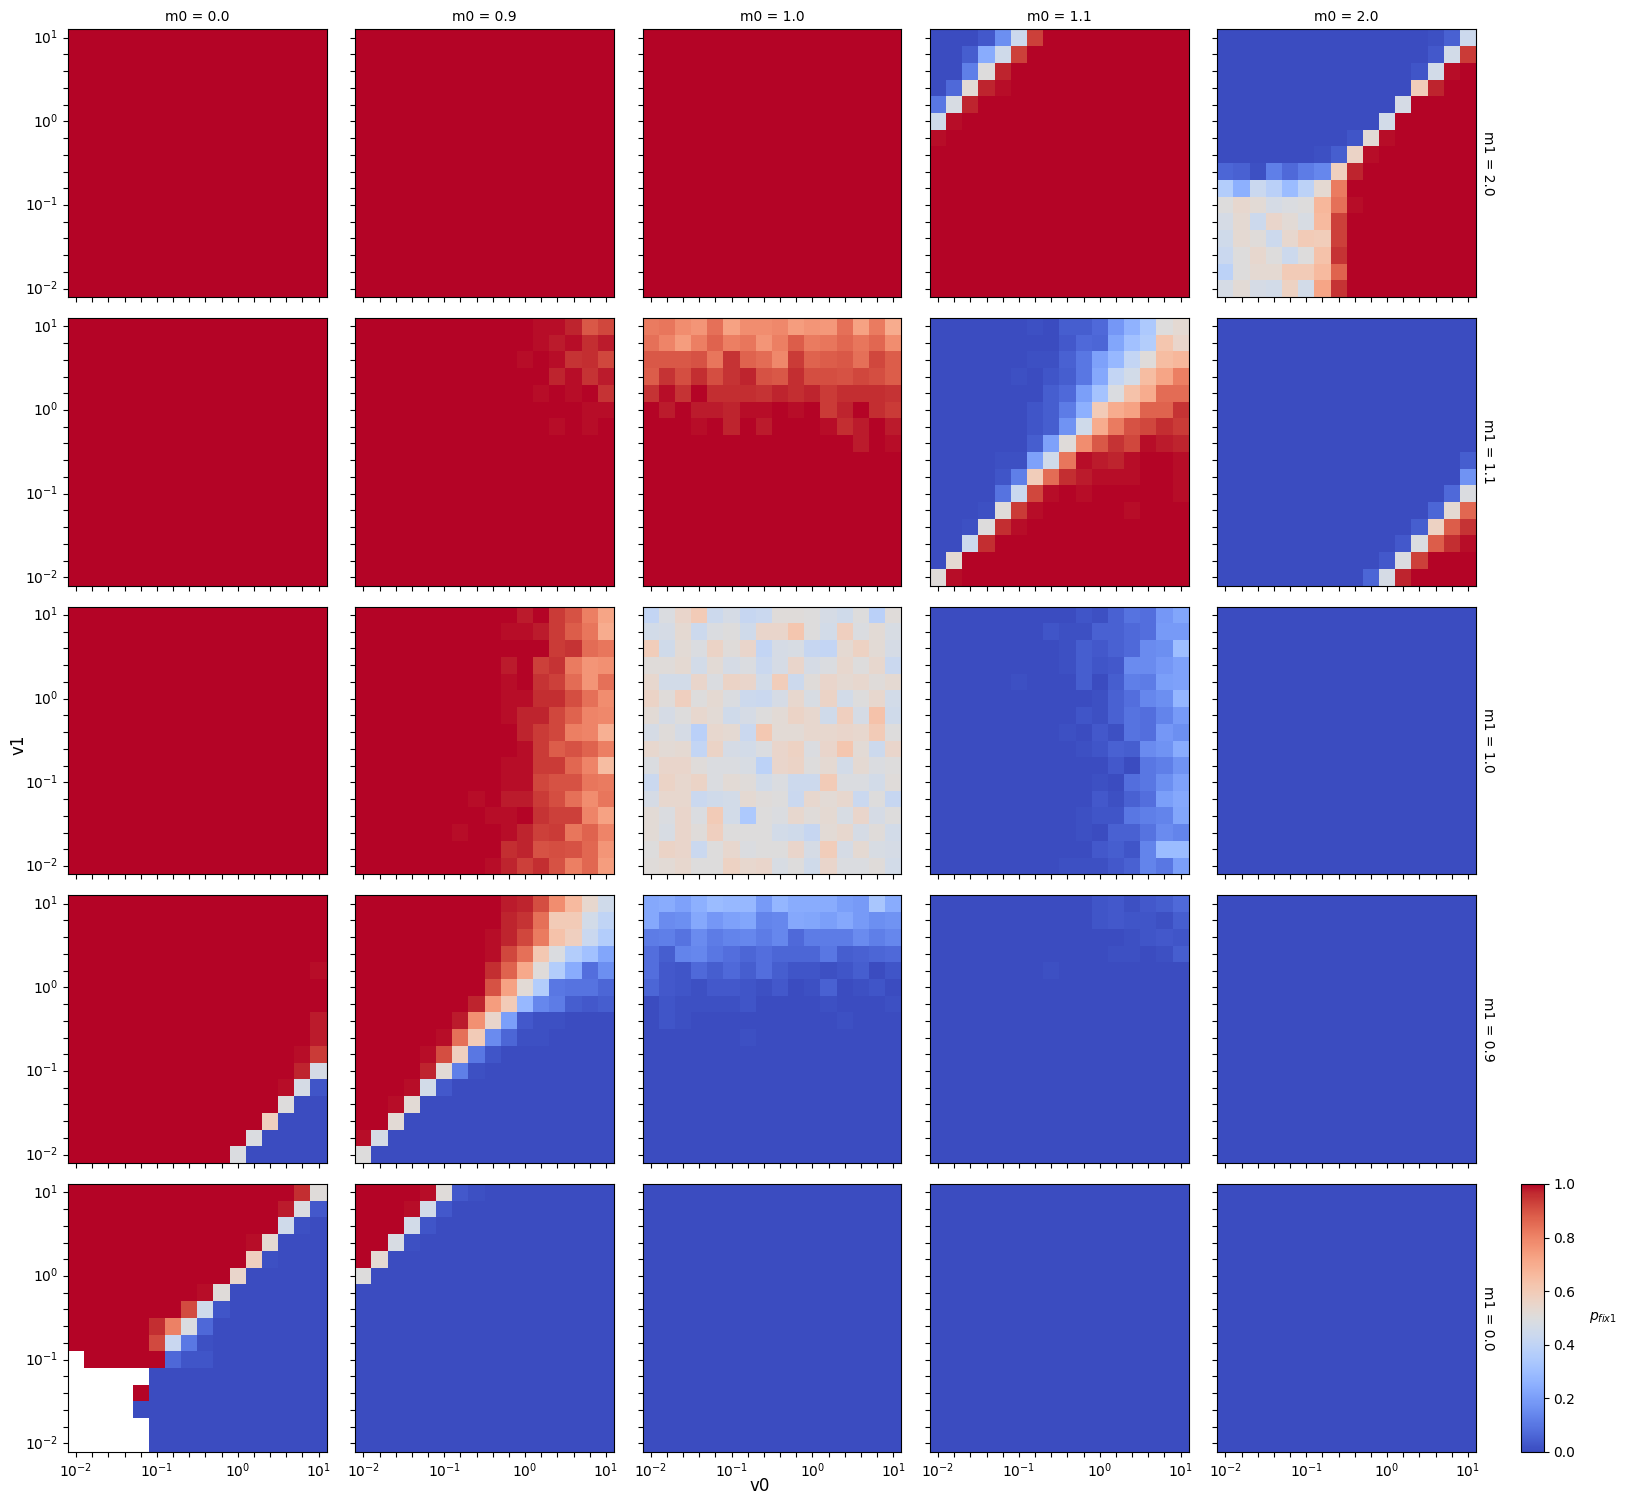

In [15]:
g = sns.FacetGrid(d_smr, row="m1", col="m0", row_order=row_order_m, col_order=col_order_m, margin_titles=True)
g.map_dataframe(heatmap_panel)
g.fig.supxlabel("v0", x = 0.5, y = 0)
g.fig.supylabel('v1', y = 0.5, x = 0)


# Add a colorbar next to the last panel
# Compute position of the last panel
last_ax = g.axes[-1, -1]  # last row, last column
pos = last_ax.get_position()  # Bbox

# Create a new Axes for the colorbar: slightly thinner than a panel
cbar_ax = g.fig.add_axes([pos.x1 + 0.03, pos.y0, 0.015, pos.height])
# Use the same colormap and normalization
sm = plt.cm.ScalarMappable(cmap="coolwarm", norm=plt.Normalize(vmin=0, vmax=1))
sm.set_array([])
#g.fig.colorbar(sm, cax=cbar_ax, orientation='vertical', label = "$p_{fix1}$")
cbar = g.fig.colorbar(sm, cax=cbar_ax, orientation='vertical')
cbar.set_label("$p_{fix1}$", rotation=0, labelpad=10, va='center', ha='left')


plt.show()

In [16]:
g.fig.savefig("L1_n1_step_summary.svg", format="svg", bbox_inches="tight")

In [17]:
g.fig.savefig("L1_n1_step_summary.pdf", format="pdf", bbox_inches="tight")

In [8]:
np.array([1,np.inf]).reshape(1,2,1)

array([[[ 1.],
        [inf]]])

In [13]:
z = np.linspace(-4,5,101).reshape((101,1))

In [14]:
w = hanoi.fit_step(z = z, boxes = np.array([1, np.inf]).reshape((1,2,1)))

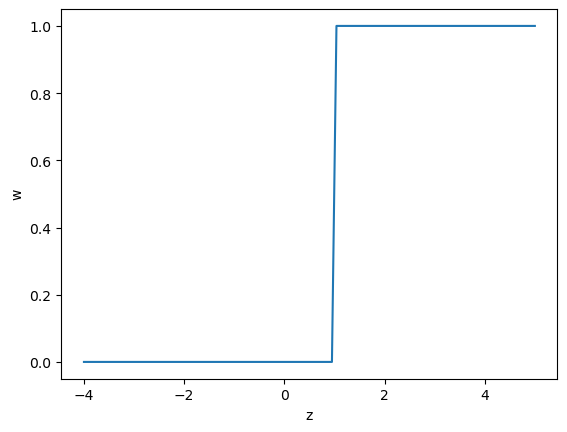

In [18]:
plt.plot(z, w)
plt.xlabel("z")
plt.ylabel("w")
plt.savefig("L1_n1_step_fitness_funcs.pdf", bbox_inches="tight")
plt.show()